In [1]:
import matplotlib.pyplot as plt
from plot_functions import plot_te_carbon_frontiers_all_periods, plot_te_carbon_by_sector

Figure saved to: results/te_carbon_frontiers_all_periods.pdf


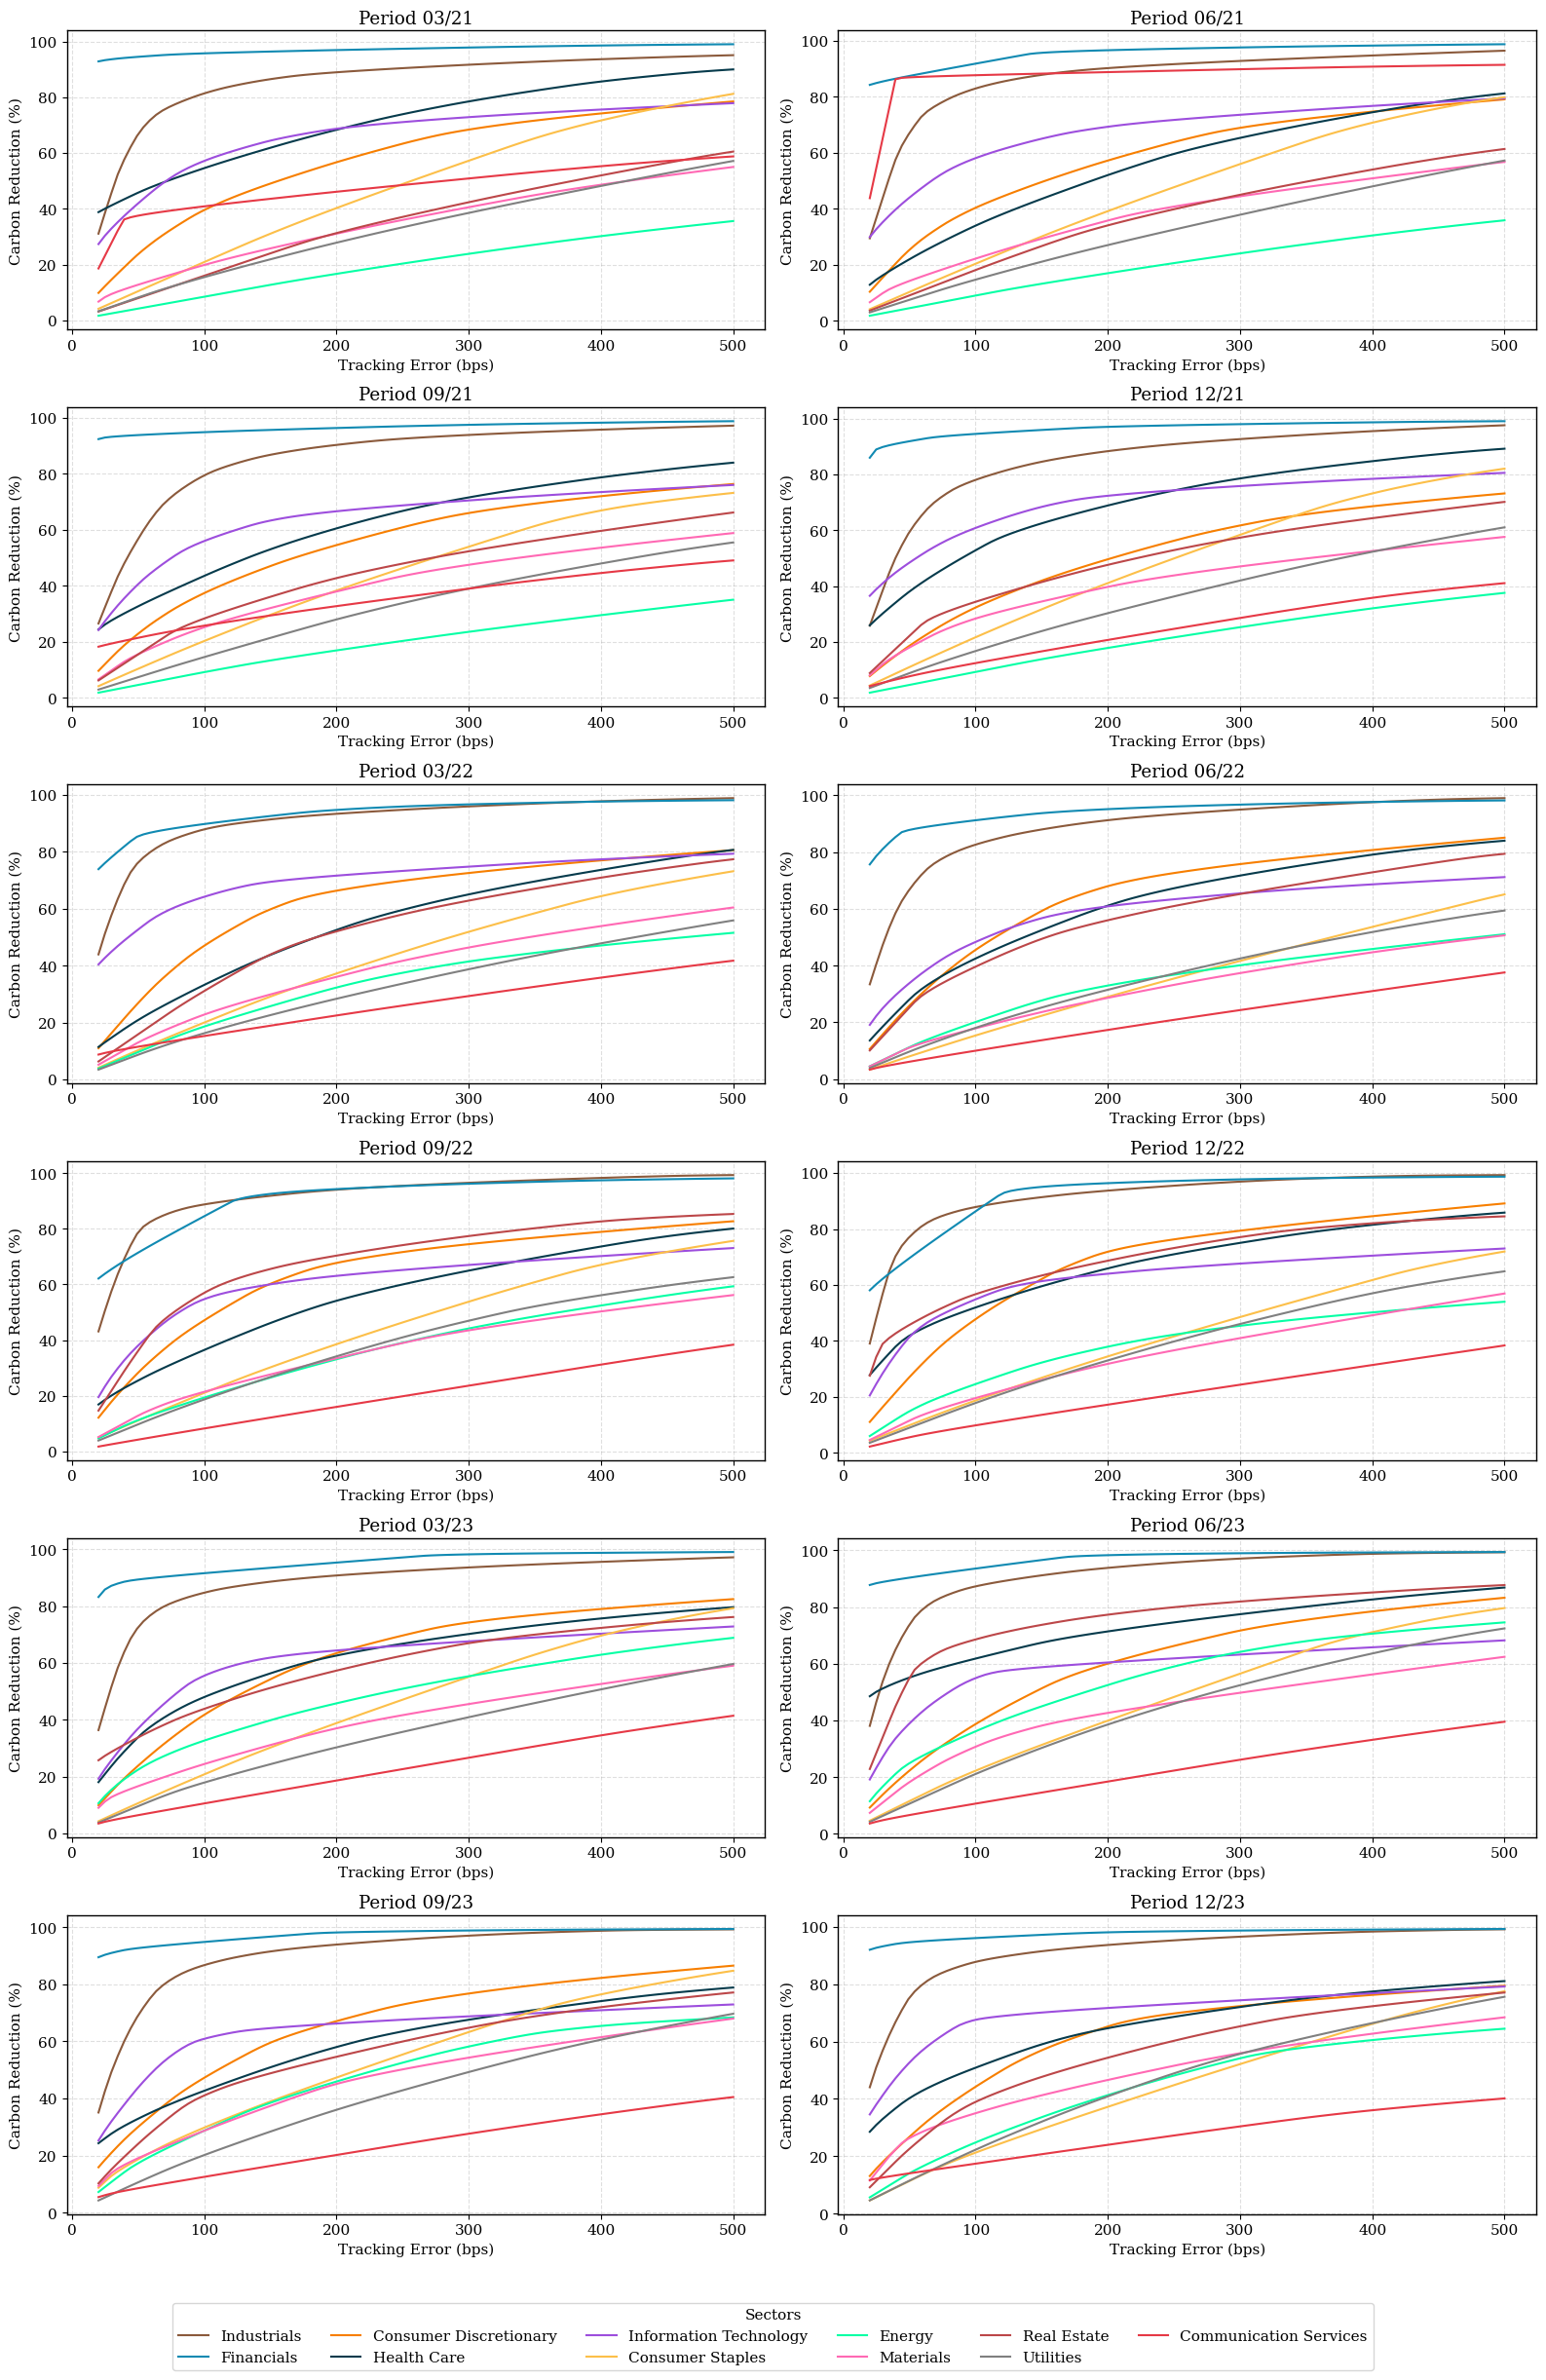

In [2]:
# Plot and save TE-Carbon frontiers for all periods
fig = plot_te_carbon_frontiers_all_periods(
    portfolio_dir="results/optimal_portfolios/",
    output_path="results/te_carbon_frontiers_all_periods.pdf"
)
plt.show()

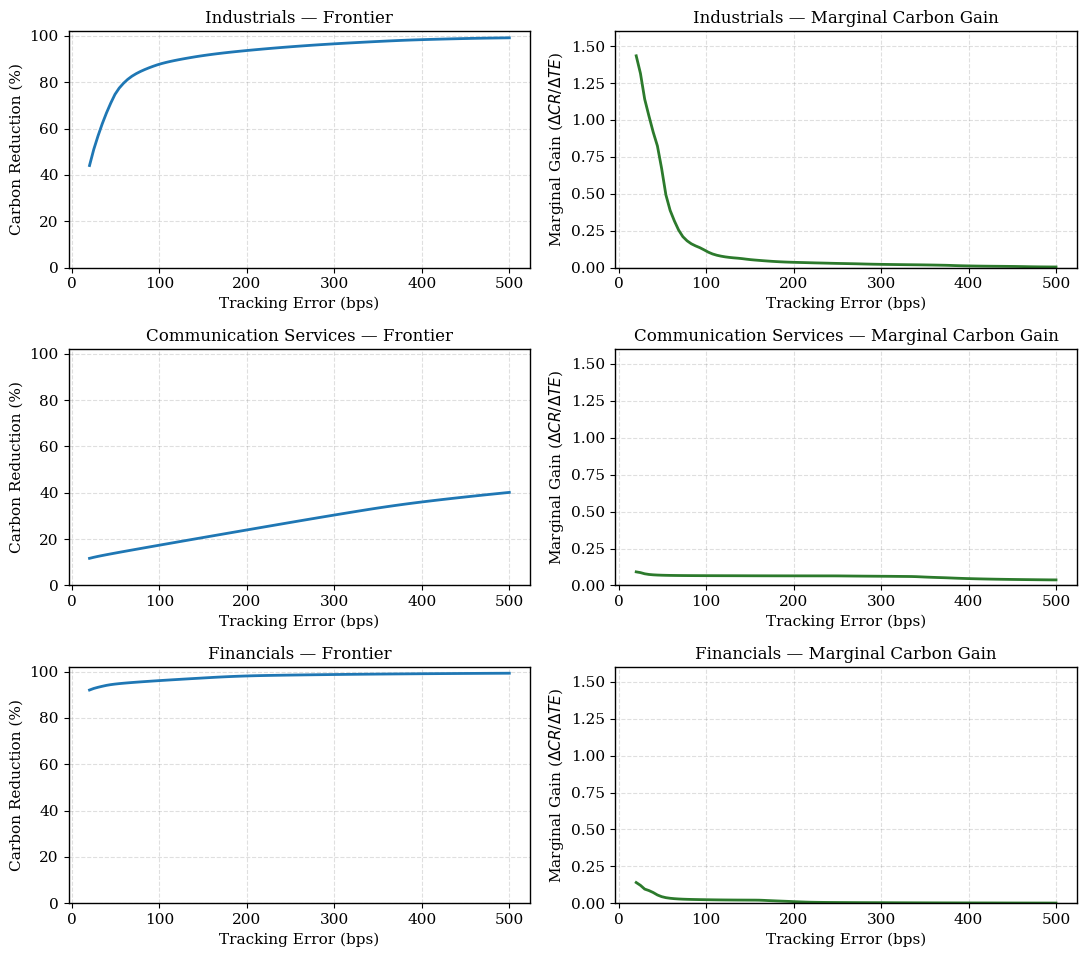

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pickle

# -----------------------
# GLOBAL ACADEMIC STYLE
# -----------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.0,
    "grid.color": "gray",
    "grid.linestyle": "--",
    "grid.alpha": 0.25,
})

# Load latest period
last_pickle = sorted(Path("results/optimal_portfolios").glob("optimal_portfolios_all_te_*.pkl"))[-1]

with open(last_pickle, "rb") as f:
    last_period = pickle.load(f)

sectors_to_plot = ["Industrials", "Communication Services", "Financials"]

fig, axes = plt.subplots(3, 2, figsize=(11, 10))

for row, sector in enumerate(sectors_to_plot):

    data = last_period[sector]
    te = np.array(data["tracking_errors"])
    cr = np.array(data["carbon_reductions"])

    # -----------------------
    # 1) Frontier
    # -----------------------
    ax_frontier = axes[row, 0]
    ax_frontier.plot(te, cr, "-", lw=2.0, color="#1f77b4")
    ax_frontier.set_title(f"{sector} — Frontier", fontsize=12)
    ax_frontier.set_xlabel("Tracking Error (bps)")
    ax_frontier.set_ylabel("Carbon Reduction (%)")
    ax_frontier.set_ylim(0, 102)   # instead of (0, 100)

    ax_frontier.grid(True)

    # -----------------------
    # 2) Marginal gains
    # -----------------------
    marginal = np.gradient(cr, te)
    ax_marg = axes[row, 1]
    ax_marg.plot(te, marginal, "-", lw=2.0, color="#2c7a2c")
    ax_marg.axhline(0, color="black", linewidth=0.8)
    ax_marg.set_title(f"{sector} — Marginal Carbon Gain", fontsize=12)
    ax_marg.set_xlabel("Tracking Error (bps)")
    ax_marg.set_ylabel(r"Marginal Gain ($\Delta CR / \Delta TE$)")
    ax_marg.set_ylim(0, 1.6)
    ax_marg.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("results/te_carbon_marginal_gains_last_period_academic.pdf", 
            bbox_inches="tight")

plt.show()
